<a href="https://colab.research.google.com/github/DulaniDeSilva/Computer-Vision/blob/main/ImageFormation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing libraries

In [ ]:
!pip install opencv-python scikit-image pandas -q

In [ ]:
!pip install datasets -q

Importing libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage import data as skimage_data
from datasets import load_dataset
from skimage import data as skimage_data

# setting a random seed
np.random.seed(42)

Step 1 - Load CIFAR-10 (with fallback) + high resoultion reference image

Image shape (32, 32, 3)
Pixel range 34 - 203
Dtype: uint8
High res image shape (300, 451, 3)

How it relates : An image is a 2D function f(x, y) where x and y discrte (32, 32 each not continuous, 3 is the the numbr of channels (RGB))

Dtype uint8 integers 0-255 are allowed, not real numbers.

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

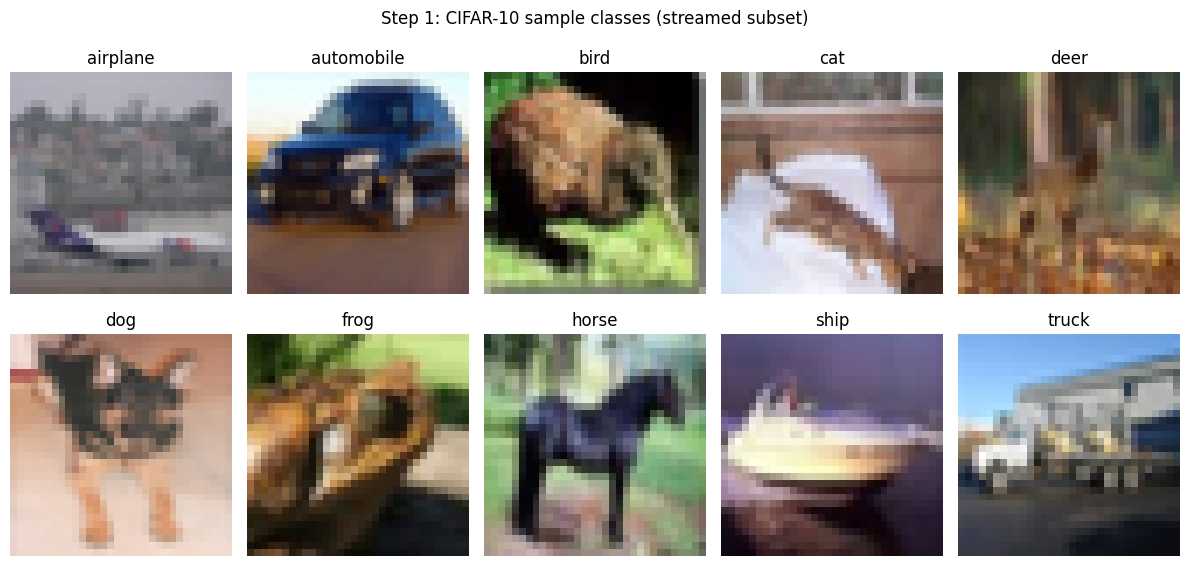

Image shape: (32, 32, 3)
Pixel range: 34 - 203
Dtype: uint8


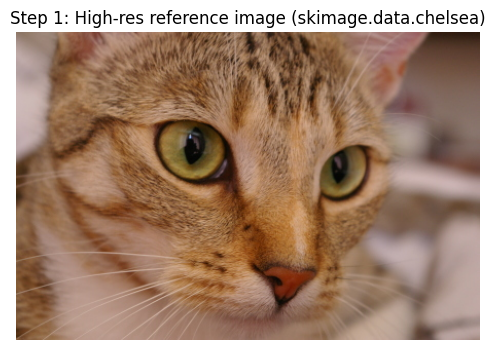

High-res image shape: (300, 451, 3)


In [ ]:
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

# Stream CIFAR-10 — pulls examples on demand, never downloads the full ~170MB set
ds = load_dataset("uoft-cs/cifar10", split="train", streaming=True)

# Walk the stream until we've collected at least one image per class
# (cap iterations so this can't run away if something's off)
samples_by_class = {}
max_iters = 5000

for i, example in enumerate(ds):
    label = example["label"]
    if label not in samples_by_class:
        samples_by_class[label] = np.array(example["img"])  # PIL -> numpy uint8
    if len(samples_by_class) == 10 or i >= max_iters:
        break

assert len(samples_by_class) == 10, f"Only found {len(samples_by_class)} classes — try increasing max_iters"

# Display one image per class
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(samples_by_class[i])
    plt.title(class_names[i])
    plt.axis("off")
plt.suptitle("Step 1: CIFAR-10 sample classes (streamed subset)")
plt.tight_layout()
plt.show()

sample_img = samples_by_class[0]
print("Image shape:", sample_img.shape)
print("Pixel range:", sample_img.min(), "-", sample_img.max())
print("Dtype:", sample_img.dtype)


subset_images = list(samples_by_class.values())  # 10 images, one per class
image = subset_images[3]  # e.g. "cat" — low-res reference for noise/quantization steps

# High-res reference — built into scikit-image, no internet needed
hires = skimage_data.chelsea()  # 300x451 RGB cat photo, ships with skimage
plt.figure(figsize=(6, 4))
plt.imshow(hires)
plt.title("Step 1: High-res reference image (skimage.data.chelsea)")
plt.axis("off")
plt.show()

print("High-res image shape:", hires.shape)

Step 2 - Illumination

change_illumination - mulitplies every pixel by a scalar factor (how much light hits the sensor)

Once a pixel hits 255, you cannot recover what the true brightness was

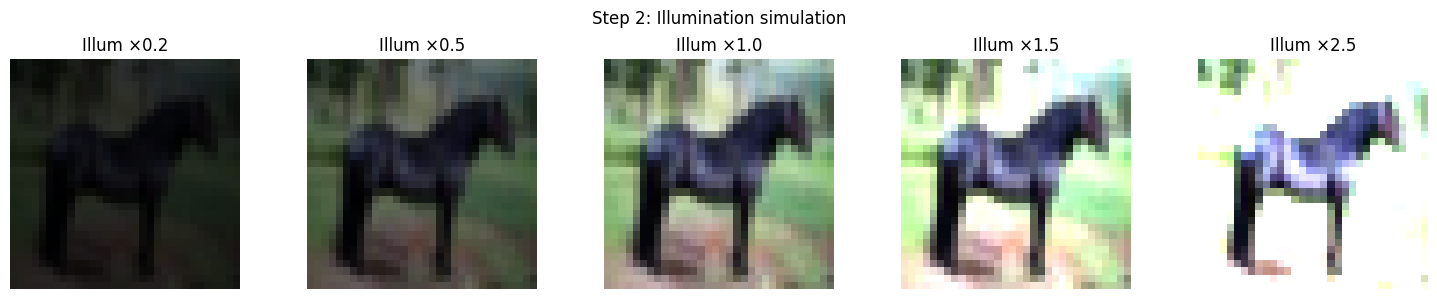

In [ ]:
def change_illumination(img, factor):
    out = img.astype(np.float32) * factor
    return np.clip(out, 0, 255).astype(np.uint8)

factors = [0.2, 0.5, 1.0, 1.5, 2.5]
results = [change_illumination(image, f) for f in factors]
titles = [f"Illum ×{f}" for f in factors]

plt.figure(figsize=(15, 3))
for i, (r, t) in enumerate(zip(results, titles)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(r); plt.title(t); plt.axis("off")
plt.suptitle("Step 2: Illumination simulation")
plt.tight_layout()
plt.show()

Step 3 - Lens effects - defocus blue + distortion (on hires image)

Defocus blur  (Gaussian blur) A lense that is not perfectly focused spreads each point of light into small blob instead of sharp point. This connects to depth of field - objects at the wrong distance from focal plane blur.

Lense distortion - simulates barrel/ pincushion distortion - real camera lense bend straight lines.

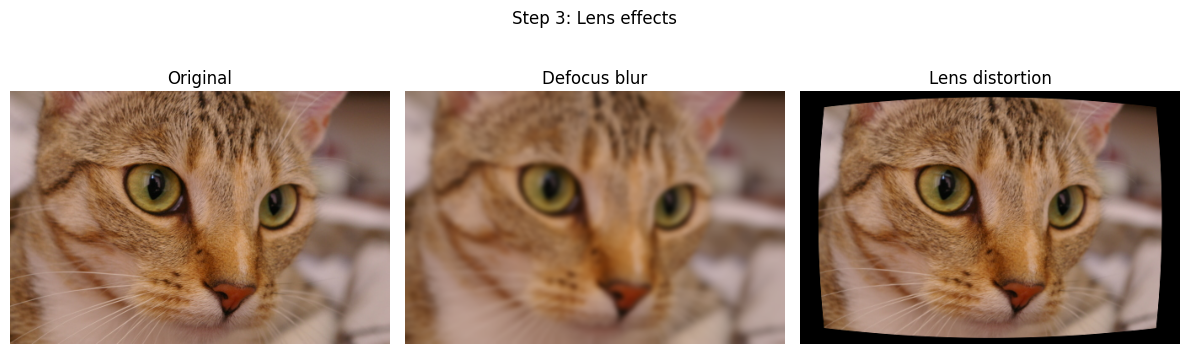

In [ ]:
def simulate_defocus_blur(img, ksize):
    ksize = ksize if ksize % 2 == 1 else ksize + 1
    return cv2.GaussianBlur(img, (ksize, ksize), 0)

def simulate_lens_distortion(img, k1=0.3, k2=0.05):
    h, w = img.shape[:2]
    camera_matrix = np.array([[w, 0, w/2],
                               [0, w, h/2],
                               [0, 0, 1]], dtype=np.float32)
    dist_coeffs = np.array([k1, k2, 0, 0], dtype=np.float32)
    return cv2.undistort(img, camera_matrix, dist_coeffs)

blurred = simulate_defocus_blur(hires, ksize=15)
distorted = simulate_lens_distortion(hires, k1=0.5, k2=0.1)

plt.figure(figsize=(12, 4))
for i, (im, t) in enumerate(zip(
        [hires, blurred, distorted],
        ["Original", "Defocus blur", "Lens distortion"])):
    plt.subplot(1, 3, i + 1)
    plt.imshow(im); plt.title(t); plt.axis("off")
plt.suptitle("Step 3: Lens effects")
plt.tight_layout()
plt.show()

Step 4 - Sensor noise

CCD/CMOS general sensor pipeline.  Gaussian noise addition simulates the physical reality that sensor's photon to electron conversion has randomness.

High sigma - modeling exactly what shows up as a gain in real low light photos and it is the reason ISO amplification makes images noisier - turning up ISO amplifies the signal and the sensor inherent noise together

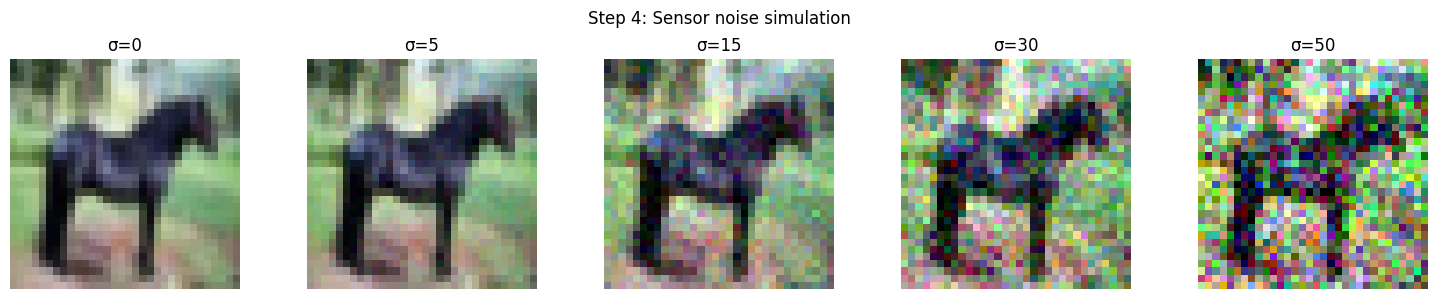

In [ ]:
def add_gaussian_noise(img, sigma):
    noisy = img.astype(np.float32) + np.random.normal(0, sigma, img.shape)
    return np.clip(noisy, 0, 255).astype(np.uint8)

sigmas = [0, 5, 15, 30, 50]
results = [add_gaussian_noise(image, s) for s in sigmas]
titles = [f"σ={s}" for s in sigmas]

plt.figure(figsize=(15, 3))
for i, (r, t) in enumerate(zip(results, titles)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(r); plt.title(t); plt.axis("off")
plt.suptitle("Step 4: Sensor noise simulation")
plt.tight_layout()
plt.show()

Step 5 - Sampling / spatial resolution (on hires image)

Downsampling by 8 and then reconstructing with neareset bilinear/bicubic gives blocky artifcats, while bilinear/ bicubic interpolate between source pixles producing smoother but slighly blurrier results.  (Similar process is happening whenever we resize image for neural network input)

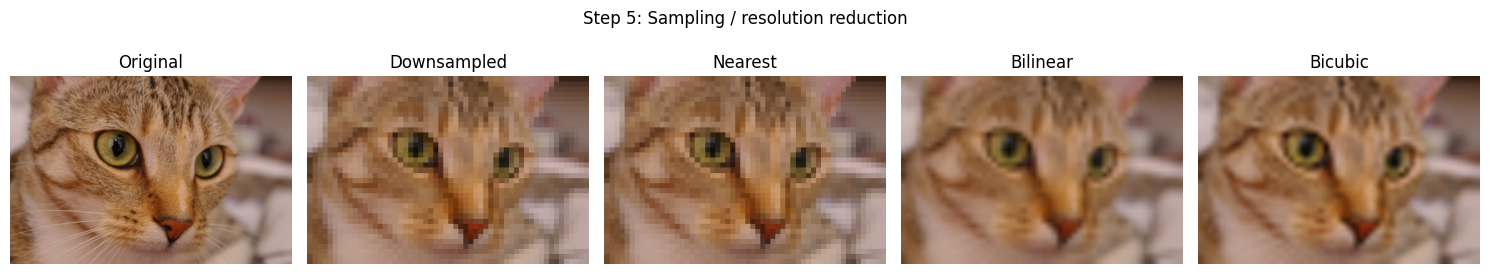

In [ ]:
def simulate_sampling(img, scale_factor):
    h, w = img.shape[:2]
    small = cv2.resize(img, (w // scale_factor, h // scale_factor),
                        interpolation=cv2.INTER_AREA)
    nearest  = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    bilinear = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
    bicubic  = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
    return small, nearest, bilinear, bicubic

small, nearest, bilinear, bicubic = simulate_sampling(hires, scale_factor=8)
small_upscaled_view = cv2.resize(small, (hires.shape[1], hires.shape[0]),
                                  interpolation=cv2.INTER_NEAREST)

titles = ["Original", "Downsampled", "Nearest", "Bilinear", "Bicubic"]
imgs = [hires, small_upscaled_view, nearest, bilinear, bicubic]

plt.figure(figsize=(15, 3))
for i, (im, t) in enumerate(zip(imgs, titles)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(im); plt.title(t); plt.axis("off")
plt.suptitle("Step 5: Sampling / resolution reduction")
plt.tight_layout()
plt.show()


Step 6 - Quantization

"values in the interval [0, L-1]... L-1 = white, 0 = black." At 2 levels, each channel becomes pure on/off — severe banding. At 256 levels (standard 8-bit), it's visually identical to the original. This is the L = 2^b relationship

2→1 bit, 4→2 bits, 256→8 bits

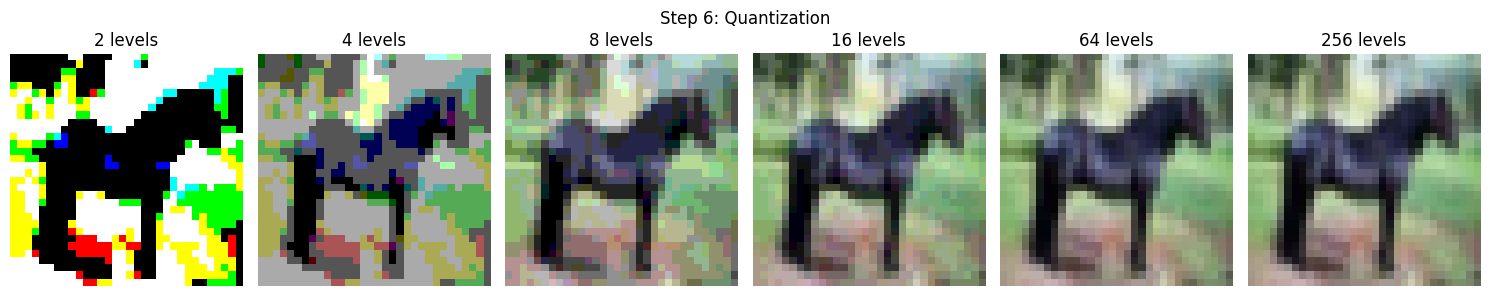

In [ ]:
def quantize_image(img, levels):
    img_f = img.astype(np.float32) / 255.0
    q = np.round(img_f * (levels - 1)) / (levels - 1)
    return np.clip(q * 255, 0, 255).astype(np.uint8)

levels_list = [2, 4, 8, 16, 64, 256]
results = [quantize_image(image, l) for l in levels_list]
titles = [f"{l} levels" for l in levels_list]

plt.figure(figsize=(15, 3))
for i, (r, t) in enumerate(zip(results, titles)):
    plt.subplot(1, 6, i + 1)
    plt.imshow(r); plt.title(t); plt.axis("off")
plt.suptitle("Step 6: Quantization")
plt.tight_layout()
plt.show()

Step 7 - Integrated pipeline

every stage together — illumination → noise → sampling → quantization → white balance → gamma — mimicking the real ISP diagram(Optics → Sensor → Demosaic → White Balance → Gamma/curve → Compress)

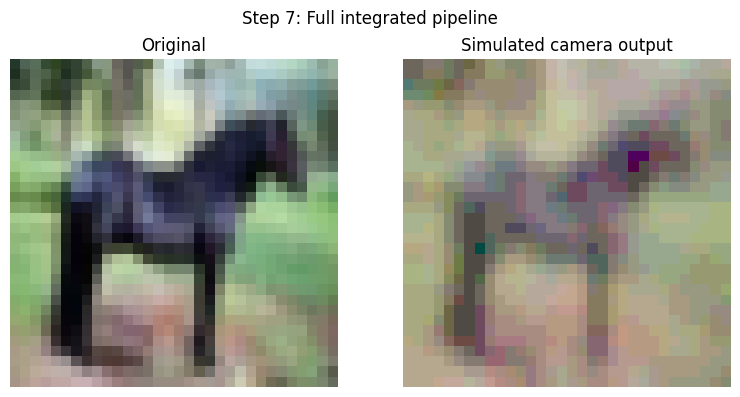

In [ ]:
def apply_white_balance(img, red_gain, green_gain, blue_gain):
    gains = np.array([red_gain, green_gain, blue_gain]).reshape(1, 1, 3)
    out = img.astype(np.float32) * gains
    return np.clip(out, 0, 255).astype(np.uint8)

def gamma_correction(img, gamma):
    img_f = img.astype(np.float32) / 255.0
    corrected = np.power(img_f, 1 / gamma)
    return np.clip(corrected * 255, 0, 255).astype(np.uint8)

def digital_camera_pipeline(img, illumination=1.0, noise_sigma=0,
                             sampling_factor=1, quantization_levels=256,
                             gamma=1.0, white_balance=(1.0, 1.0, 1.0)):
    result = img.astype(np.float32) * illumination
    result = np.clip(result, 0, 255)

    if noise_sigma > 0:
        result = result + np.random.normal(0, noise_sigma, result.shape)
        result = np.clip(result, 0, 255)

    result = result.astype(np.uint8)

    if sampling_factor > 1:
        h, w = result.shape[:2]
        result = cv2.resize(result, (w // sampling_factor, h // sampling_factor),
                             interpolation=cv2.INTER_AREA)
        result = cv2.resize(result, (w, h), interpolation=cv2.INTER_LINEAR)

    result = quantize_image(result, quantization_levels)
    result = apply_white_balance(result, *white_balance)
    result = gamma_correction(result, gamma)
    return result

processed = digital_camera_pipeline(
    image, illumination=0.6, noise_sigma=15, sampling_factor=2,
    quantization_levels=16, gamma=2.2, white_balance=(1.2, 1.0, 0.85)
)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(image); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(processed); plt.title("Simulated camera output"); plt.axis("off")
plt.suptitle("Step 7: Full integrated pipeline")
plt.tight_layout()
plt.show()

Step 8 - Quantitative evaluation

MSE/PSNR/SSIM are the standard way image restoration and super resolution(denoising, deblurring, super resolution, generative image models)

/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


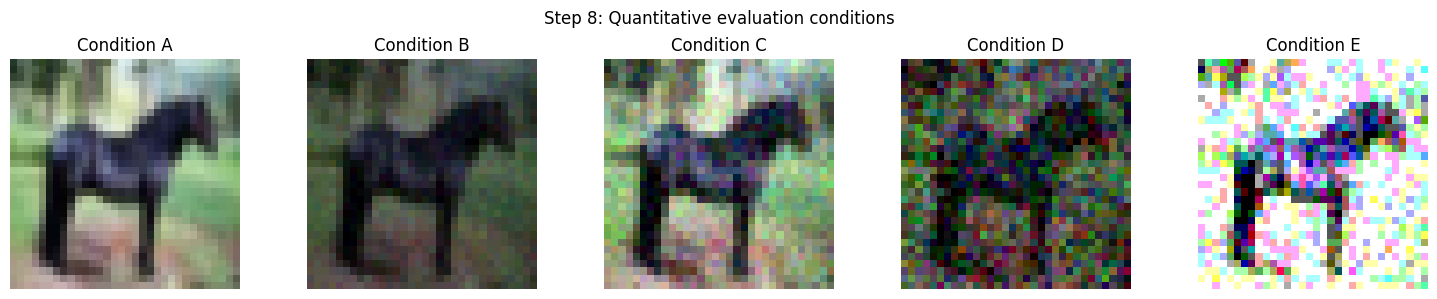

  label  illumination  noise_sigma  quantization_levels      MSE   PSNR  \
0     A           1.0            0                  256  0.00000    inf   
1     B           0.5            5                  256  0.06646  11.77   
2     C           1.0           15                   64  0.00329  24.82   
3     D           0.5           30                   16  0.07782  11.09   
4     E           2.0           50                    4  0.12493   9.03   

     SSIM  
0  1.0000  
1  0.6278  
2  0.9200  
3  0.4376  
4  0.5050  


In [ ]:
def calculate_metrics(original, processed):
    orig_f = original.astype(np.float32) / 255.0
    proc_f = processed.astype(np.float32) / 255.0
    mse = np.mean((orig_f - proc_f) ** 2)
    psnr = peak_signal_noise_ratio(orig_f, proc_f, data_range=1.0)
    ssim = structural_similarity(orig_f, proc_f, channel_axis=2, data_range=1.0)
    return mse, psnr, ssim

conditions = [
    {"label": "A", "illumination": 1.0, "noise_sigma": 0,  "quantization_levels": 256},
    {"label": "B", "illumination": 0.5, "noise_sigma": 5,  "quantization_levels": 256},
    {"label": "C", "illumination": 1.0, "noise_sigma": 15, "quantization_levels": 64},
    {"label": "D", "illumination": 0.5, "noise_sigma": 30, "quantization_levels": 16},
    {"label": "E", "illumination": 2.0, "noise_sigma": 50, "quantization_levels": 4},
]

rows = []
processed_images = []
for c in conditions:
    out = digital_camera_pipeline(
        image, illumination=c["illumination"], noise_sigma=c["noise_sigma"],
        quantization_levels=c["quantization_levels"]
    )
    processed_images.append(out)
    mse, psnr, ssim = calculate_metrics(image, out)
    rows.append({**c, "MSE": round(mse, 5), "PSNR": round(psnr, 2), "SSIM": round(ssim, 4)})

df = pd.DataFrame(rows)

plt.figure(figsize=(15, 3))
for i, (im, c) in enumerate(zip(processed_images, conditions)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(im); plt.title(f"Condition {c['label']}"); plt.axis("off")
plt.suptitle("Step 8: Quantitative evaluation conditions")
plt.tight_layout()
plt.show()

print(df)
df.to_csv("quantitative_results.csv", index=False)

Homework: Find what these values depicts and what the image results describes!!!

---

